In [2]:
# Import Statements
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
%matplotlib widget


### Aim 2.1: Can hnRNPD dependent features of RNA regulation predict DEGs from non-DEGs?

In [3]:
# This data contains all the targets of hnRNPD found in the TRAP-seq set for 60min and 15min timepoints for both shock/hc and shock/box sets.
p45_60_box = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_60_min_shock_box.csv")
p45_60_hc = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_60_min_shock_hc.csv")
p45_15_box = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_15_min_shock_box.csv")
p45_15_hc = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_15_min_shock_hc.csv")

In [4]:
# This data contains all the targets of hnRNPD found in the TRAP-seq set for 60min and 15min timepoints for both shock/hc and shock/box sets.
p42_60_hc = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p42/p42_Camk2a_60_min_shock_hc.csv")
# p45_60_hc = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_60_min_shock_hc.csv")
# p45_15_box = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_15_min_shock_box.csv")
# p45_15_hc = pd.read_csv("/Users/emmanuelmakinde/Documents/00_Project_hnRNPD/001_Machine_Learning/Isoform_Specific_Data_Matrices/p45/p45_Camk2a_15_min_shock_hc.csv")

In [5]:
# Define the feature groups
binding = ['n_clusters_x', 'total_ReadCount', 'mean_ModeScore']
regions = ['frac_utr3','frac_intron', 'frac_utr5', 'frac_cds']
all = ['n_clusters_x', 'total_ReadCount', 'mean_ModeScore','frac_utr3','frac_intron']


In [6]:
# # Initially I resampled the data, then I met the glorious, Robert Carney. I became, again, a man.
# mask = dataset['Expression'] == 0
# up_df = dataset[~mask]
# down_df = dataset[mask]
# from sklearn.utils import resample
# df_upsample = resample(down_df,replace=True, n_samples=len(up_df), random_state=42)
# dataset = pd.concat([up_df,df_upsample])
# dataset['Expression'].value_counts()
# # BAD FOR DATA LEAKAGE.

[0.48912362 0.26135288 0.24952351]


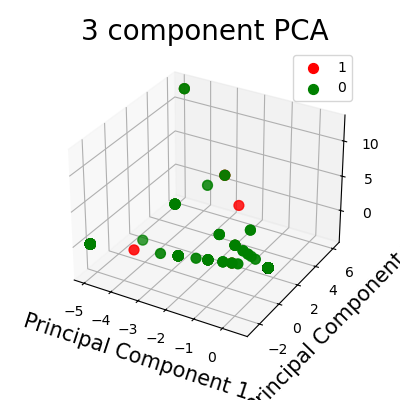

In [7]:
X = p42_60_hc[regions]
X = StandardScaler().fit_transform(X)

pca = PCA(n_components=3)

principalComponents = pca.fit_transform(X)

principalDf = pd.DataFrame(data = principalComponents
             , columns = ['principal component 1', 'principal component 2', 'principal component 3'])

finalDf = pd.concat([principalDf, p42_60_hc[['Expression']]], axis = 1)

fig = plt.figure(figsize = (4,4))
ax = fig.add_subplot(1,1,1, projection='3d') 
ax.set_xlabel('Principal Component 1', fontsize = 15)
ax.set_ylabel('Principal Component 2', fontsize = 15)
ax.set_title('3 component PCA', fontsize = 20)

print(pca.explained_variance_ratio_)

targets = [1, 0]
colors = ['r', 'g']
for target, color in zip(targets, colors):
    indicesToKeep = finalDf['Expression'] == target
    ax.scatter(finalDf.loc[indicesToKeep, 'principal component 1']
               , finalDf.loc[indicesToKeep, 'principal component 2']
               , finalDf.loc[indicesToKeep, 'principal component 3']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()

/opt/anaconda3/envs/codingpractice/lib/python3.13/site-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/opt/anaconda3/envs/codingpractice/lib/python3.13/site-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/opt/anaconda3/envs/codingpractice/lib/python3.13/site-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/opt/anaconda3/envs/codingpractice/lib/python3.13/site-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2), which may not be intended.
  func(x=x, y=y, **kwargs)
/opt/anaconda3/envs/codingpractice/lib/python3.13/site-packages/seaborn/axisgrid.py:1615: UserWarning: The markers list has more values (3) than needed (2),

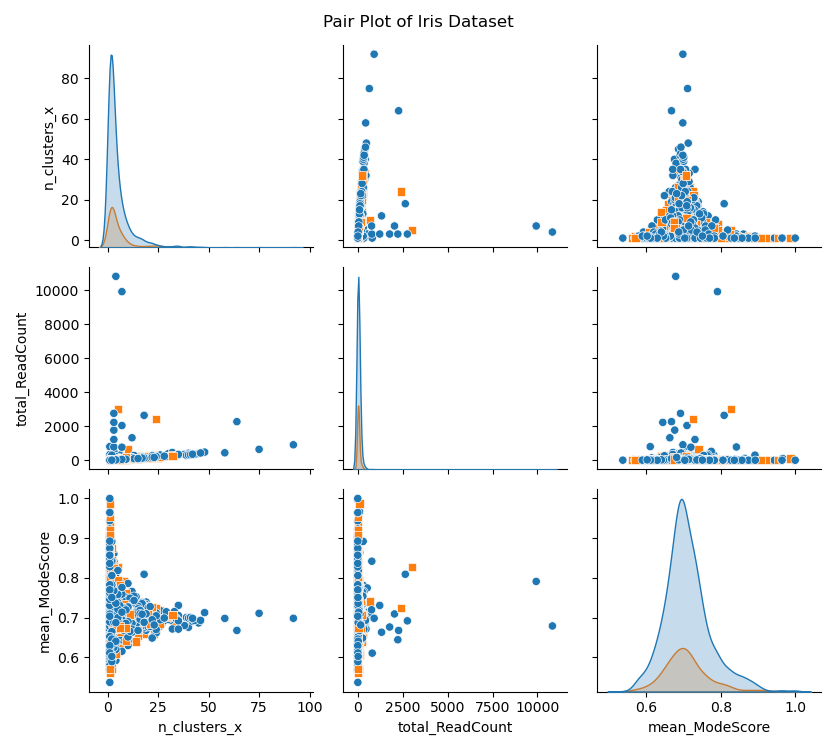

In [ ]:
all_features_columns = ['n_clusters_x', 'frac_utr3', 'frac_utr5', 'frac_cds',
       'frac_intron', 'total_ReadCount', 'mean_ModeScore', 'Isoform',
        'Time', 'denominator', 'Isoform_p37', 'Isoform_p40',
       'Isoform_p42', 'Isoform_p45', 'Denominator_box',
       'Denominator_homecage']
regions_columns = ['frac_utr3', 'frac_utr5', 'frac_cds', 'frac_intron']

binding_dataset = p45_60_box[['Expression','frac_utr3', 'frac_utr5', 'frac_cds', 'frac_intron']]
binding_features = p45_60_box[['Expression','n_clusters_x','total_ReadCount', 'mean_ModeScore']]
X = p45_60_box[binding]
y = p45_60_box['Expression']

# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

# Create a pair plot to visualize relationships between different features and species.
ax = sns.pairplot(binding_features, hue='Expression', markers=["o", "s", "D"])
plt.suptitle("Pair Plot of Iris Dataset")
sns.move_legend(
    ax, "lower center",
    bbox_to_anchor=(.5, 1), ncol=3, title=None, frameon=False)
plt.tight_layout()
plt.show()

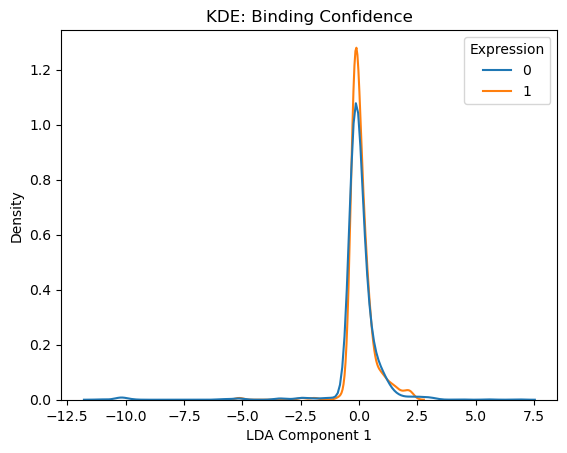

/var/folders/4y/9yl3btzn7r7b7xfvfw2_74t80000gn/T/ipykernel_2790/1992322903.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper right')


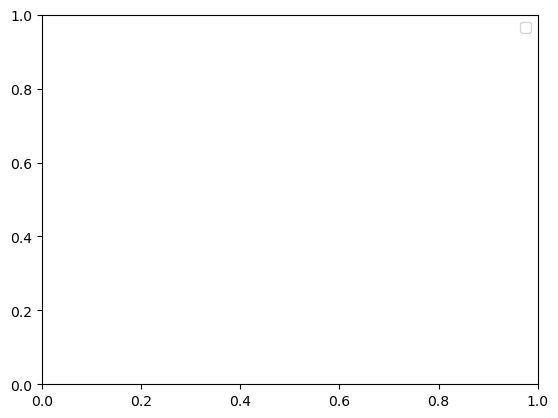

In [ ]:
p45_60_box_ALL = p45_60_box[['frac_utr3', 'frac_utr5', 'frac_cds', 'frac_intron','n_clusters_x','total_ReadCount', 'mean_ModeScore']]
p45_60_box_BINDING = p45_60_box[['n_clusters_x', 'mean_ModeScore','total_ReadCount']]
p45_60_box_REGION = p45_60_box[['frac_utr3', 'frac_utr5', 'frac_cds', 'frac_intron']]

# Change X
X = p45_60_box_ALL
y = p45_60_box['Expression']


# Encode the target variable
le = LabelEncoder()
y = le.fit_transform(y)

# Apply Linear Discriminant Analysis
X_train, X_test, y_train, y_test = train_test_split(X ,y, test_size=0.2, stratify=y)
lda = LinearDiscriminantAnalysis(n_components=1)
X_train = lda.fit_transform(X_train, y_train)
X_test = lda.transform(X_test)

tmp_Df = pd.DataFrame(X_train, columns=['LDA Component 1'])
tmp_Df['Expression']=y_train

sns.kdeplot(
    data=tmp_Df,
    x="LDA Component 1",
    hue="Expression",
    common_norm=False,
)
plt.title("KDE: Binding Confidence")
plt.show()
plt.legend(loc='upper right')

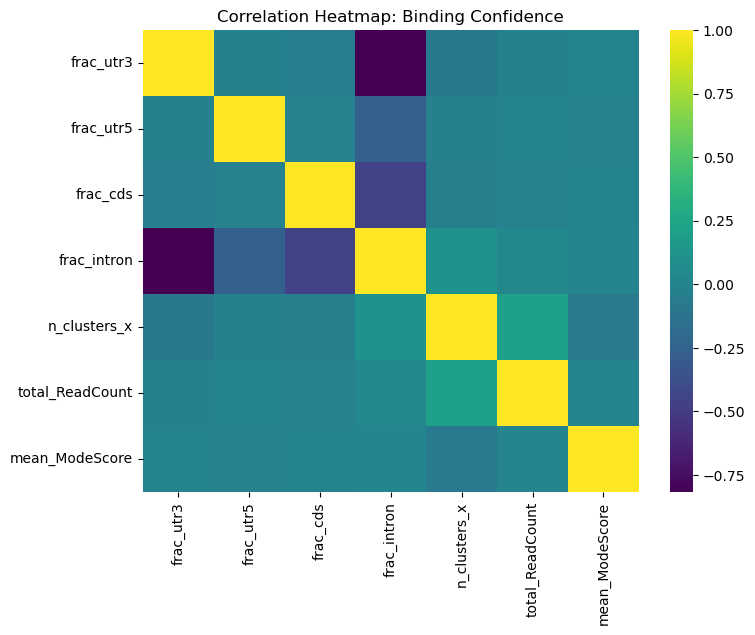

In [66]:
correlation_matrix = p45_60_box_ALL.corr(numeric_only = True)
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=False, cmap='viridis', linewidths=0)
plt.title("Correlation Heatmap: Binding Confidence")
plt.show()

NameError: name 'p45_60_box_ALL' is not defined

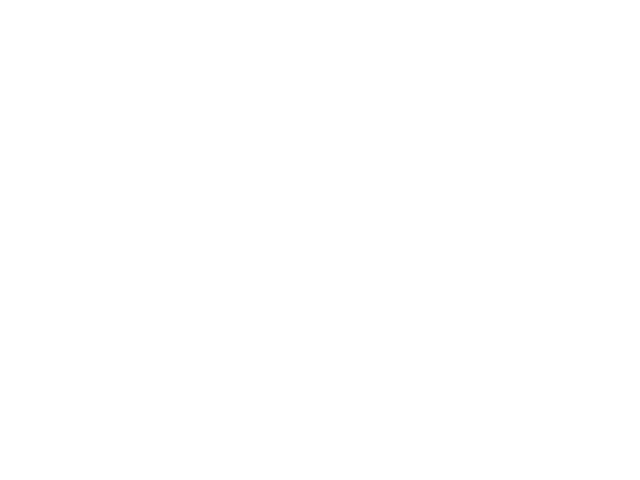

In [15]:
plt.figure()
plt.bar(p45_60_box_ALL['frac_intron'])
plt.show()